# AI vs Human Text Detection
## Phase 1: Data Loading & Preprocessing

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [20]:
# Load the dataset
df = pd.read_csv('data/raw/data_for_preprocessing.csv')
df.head()

,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human


In [21]:
# Explore data
print("Author distribution:")
print(df['Author'].value_counts())
print(f"\nClass balance: {df['Author'].value_counts(normalize=True).round(3).to_dict()}")

Author distribution:
Author
AI       3069
Human    3000
Name: count, dtype: int64

Class balance: {'AI': 0.506, 'Human': 0.494}


In [22]:
# Preview sample texts
print("Sample AI-generated text:")
print(df[df['Author'] == 'AI']['Text'].iloc[0][:200], "...\n")
print("Sample Human-written text:")
print(df[df['Author'] == 'Human']['Text'].iloc[0][:200], "...")

Sample AI-generated text:
This study investigates the chemical composition of thermal springs in Afyonkarahisar, assessing their potential for health tourism. ...

Sample Human-written text:
 Isolation of human peripheral blood mononuclear cells (PBMCs) from blood typically involves a density gradient medium during density centrifugation. The problem of increasing red blood cell (RBC) and ...


Retaining stopwords and punctuation is essential because they reveal the structural rhythm of how sentences are built, rather than just what they mean.

Stopwords (common “function” words):
the, is, at, which, on, and, but, or, in, of, to, for, with, as, by

Punctuation (symbols for structure):
. , ! ? ; : ' " ( ) [ ] { } - — … / \ @ # $ % & *

In [24]:
# Preprocessing: Lowercase only - keep all punctuation
def preprocess_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower()

df['processed_text'] = df['Text'].apply(preprocess_text)
df['label'] = (df['Author'] == 'AI').astype(int)
print("Preprocessing complete!")
print(f"Label distribution: {df['label'].value_counts().to_dict()}")

Preprocessing complete!
Label distribution: {1: 3069, 0: 3000}


## Visualization: Original Data - Text Lengths

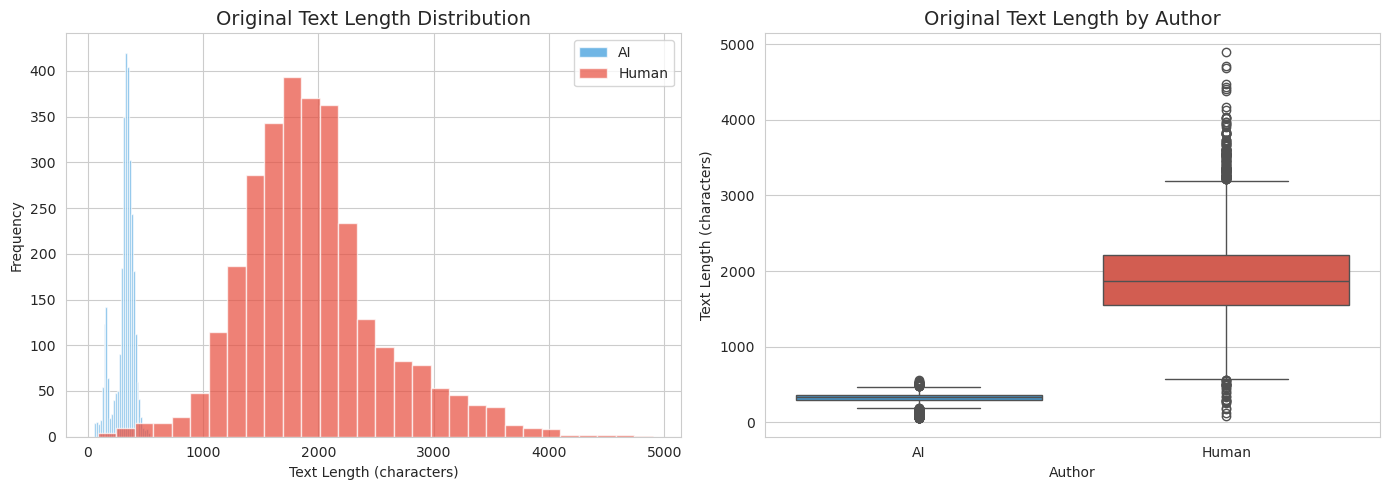


Original Text Length Stats:
         count         mean         std   min     25%     50%     75%     max
Author                                                                       
AI      3069.0   313.435973   85.414674  51.0   292.0   332.0   365.0   556.0
Human   3000.0  1943.590667  612.266781  83.0  1552.0  1873.0  2214.0  4901.0


In [25]:
# Visualize original text lengths
df['text_length'] = df['Text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Author'] == 'AI']['text_length'], bins=30, alpha=0.7, label='AI', color='#3498db')
axes[0].hist(df[df['Author'] == 'Human']['text_length'], bins=30, alpha=0.7, label='Human', color='#e74c3c')
axes[0].set_title('Original Text Length Distribution', fontsize=14)
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

colors = ['#3498db', '#e74c3c']
sns.boxplot(x='Author', y='text_length', data=df, ax=axes[1], hue='Author', palette=colors, legend=False)
axes[1].set_title('Original Text Length by Author', fontsize=14)
axes[1].set_ylabel('Text Length (characters)')

plt.tight_layout()
plt.show()

print(f"\nOriginal Text Length Stats:")
print(df.groupby('Author')['text_length'].describe())

In [29]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['processed_text'],
    df_balanced['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining labels: AI={y_train.sum()}, Human={len(y_train)-y_train.sum()}")
print(f"Test labels: AI={y_test.sum()}, Human={len(y_test)-y_test.sum()}")

Training set: 4800 samples
Test set: 1200 samples

Training labels: AI=2400, Human=2400
Test labels: AI=600, Human=600


## Phase 2: Feature Engineering (TF-IDF + N-grams)

In [30]:
from collections import Counter
import math

# Generate N-grams
def generate_ngrams(text, n):
    words = text.split()
    ngrams = []
    for i in range(len(words) - n + 1):
        ngram = ' '.join(words[i:i+n])
        ngrams.append(ngram)
    return ngrams

# Test
test_text = "the quick brown fox jumps"
print("Testing n-gram generation:")
print(f"Original: '{test_text}'")
print(f"Bigrams: {generate_ngrams(test_text, 2)}")
print(f"Trigrams: {generate_ngrams(test_text, 3)}")

Testing n-gram generation:
Original: 'the quick brown fox jumps'
Bigrams: ['the quick', 'quick brown', 'brown fox', 'fox jumps']
Trigrams: ['the quick brown', 'quick brown fox', 'brown fox jumps']


In [31]:
# Build vocabulary
def build_vocabulary(texts, n):
    vocab = set()
    for text in texts:
        ngrams = generate_ngrams(text, n)
        vocab.update(ngrams)
    return {ng: i for i, ng in enumerate(sorted(vocab))}

# Build vocabulary with unigrams
vocab = build_vocabulary(df_balanced['processed_text'], 1)
print(f"Vocabulary size (unigrams): {len(vocab)}")

Vocabulary size (unigrams): 82827


In [35]:
# TF-IDF from scratch
class TFIDFVectorizer:
    def __init__(self, n=1):
        self.n = n
        self.vocabulary_ = {}
        self.idf_ = {}

    def fit(self, texts):
        self.vocabulary_ = build_vocabulary(texts, self.n)
        num_docs = len(texts)
        doc_freq = Counter()
        for text in texts:
            ngrams = set(generate_ngrams(text, self.n))
            for ng in ngrams:
                if ng in self.vocabulary_:
                    doc_freq[ng] += 1
        for term, df in doc_freq.items():
            self.idf_[term] = math.log(num_docs / df)
        return self

    def transform(self, texts):
        num_terms = len(self.vocabulary_)
        vectors = []
        for text in texts:
            ngrams = generate_ngrams(text, self.n)
            tf = Counter(ngrams)
            vector = np.zeros(num_terms)
            for term, tf_count in tf.items():
                if term in self.vocabulary_:
                    idx = self.vocabulary_[term]
                    idf = self.idf_.get(term, 0)
                    vector[idx] = tf_count * idf
            vectors.append(vector)
        return np.array(vectors)

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

# Test with unigrams
tfidf = TFIDFVectorizer(n=1)
X_tfidf = tfidf.fit_transform(df_balanced['processed_text'])
print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Sample vector (first 10): {X_tfidf[0][:10]}")

TF-IDF matrix shape: (6000, 82827)
Sample vector (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Phase 2 Visualization: Vocabulary & TF-IDF

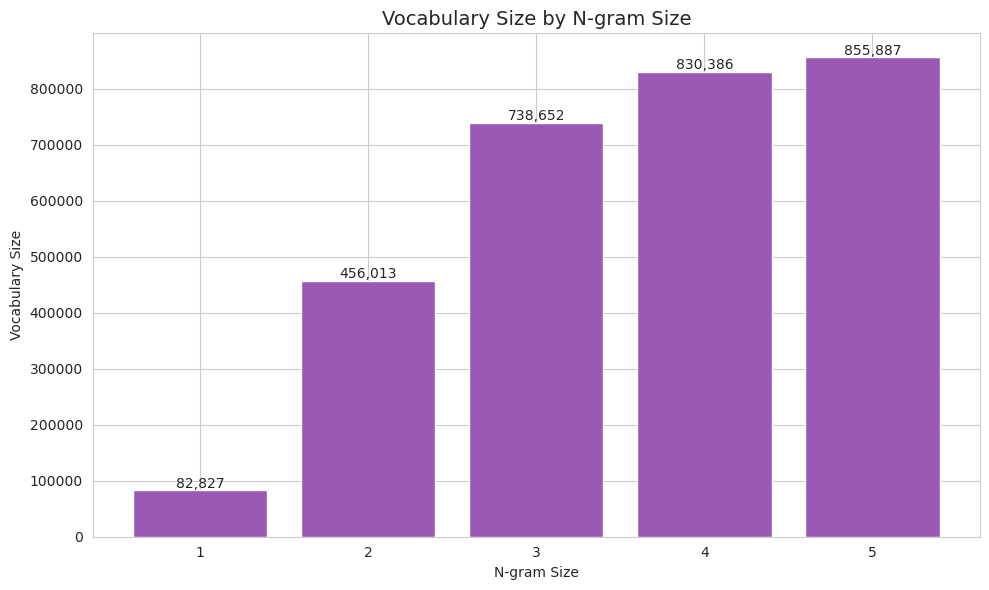


Vocabulary sizes by N-gram:
  1-gram: 82,827 terms
  2-gram: 456,013 terms
  3-gram: 738,652 terms
  4-gram: 830,386 terms
  5-gram: 855,887 terms


In [36]:
# Vocabulary size vs N-gram size (1-5)
vocab_sizes = []
for n in range(1, 6):
    vocab = build_vocabulary(df_balanced['processed_text'], n)
    vocab_sizes.append(len(vocab))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), vocab_sizes, color='#9b59b6')
ax.set_title('Vocabulary Size by N-gram Size', fontsize=14)
ax.set_xlabel('N-gram Size')
ax.set_ylabel('Vocabulary Size')
ax.set_xticks(range(1, 6))
for i, v in enumerate(vocab_sizes):
    ax.text(i+1, v + 5000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nVocabulary sizes by N-gram:")
for n, size in enumerate(vocab_sizes, 1):
    print(f"  {n}-gram: {size:,} terms")

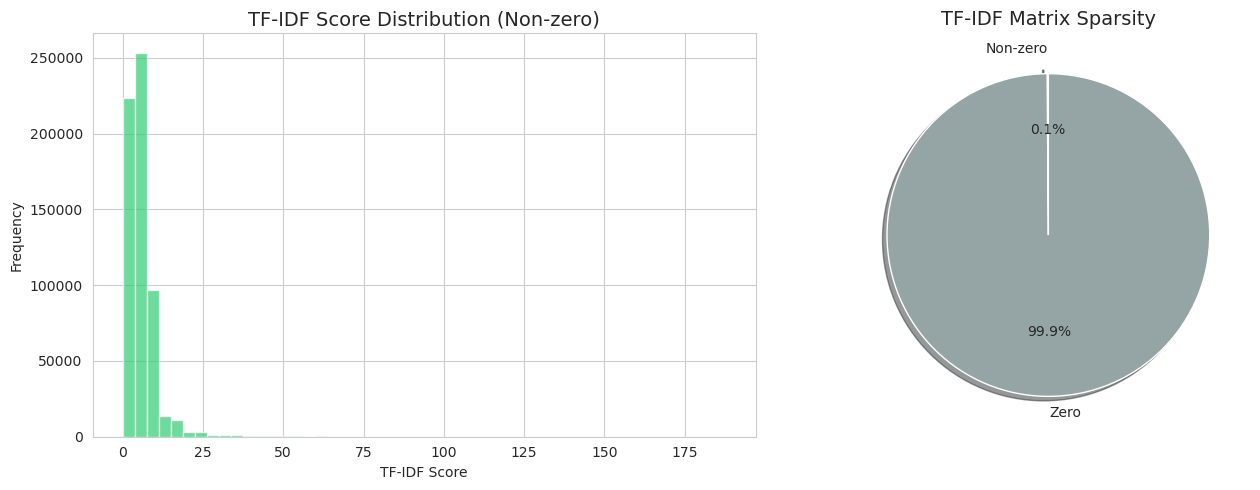

Matrix shape: (6000, 82827)
Sparsity: 99.9% zeros
Density: 0.1% non-zero


In [38]:
# TF-IDF score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tfidf_flat = X_tfidf.flatten()
nonzero_tfidf = tfidf_flat[tfidf_flat > 0]

axes[0].hist(nonzero_tfidf, bins=50, color='#2ecc71', alpha=0.7)
axes[0].set_title('TF-IDF Score Distribution (Non-zero)', fontsize=14)
axes[0].set_xlabel('TF-IDF Score')
axes[0].set_ylabel('Frequency')

sparsity = (X_tfidf == 0).sum() / X_tfidf.size * 100
density = 100 - sparsity

axes[1].pie([density, sparsity], labels=['Non-zero', 'Zero'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#95a5a6'],
        explode=(0.05, 0), shadow=True, startangle=90)
axes[1].set_title('TF-IDF Matrix Sparsity', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Matrix shape: {X_tfidf.shape}")
print(f"Sparsity: {sparsity:.1f}% zeros")
print(f"Density: {density:.1f}% non-zero")

## Phase 3: Logistic Regression (from scratch)

In [ ]:
# Sigmoid function
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# Test sigmoid
print("Sigmoid test:")
print(f"  sigmoid(0) = {sigmoid(0)}")
print(f"  sigmoid(1) = {sigmoid(1):.4f}")
print(f"  sigmoid(-1) = {sigmoid(-1):.4f}")

In [ ]:
# Logistic Regression with L1 regularization
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000, C=0.1):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(linear)

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # L1 regularization: lambda = 1/C
            reg = 1.0 / self.C
            dw += reg * np.sign(self.weights)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict(self, X, threshold=0.5):
        return (sigmoid(np.dot(X, self.weights) + self.bias) >= threshold).astype(int)

print("LogisticRegression class defined!")

In [ ]:
# F1 Score from scratch
def f1_score(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return f1, precision, recall

print("F1 score function defined!")

In [ ]:
# Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df_balanced['label'].values, test_size=0.2, random_state=42, stratify=df_balanced['label']
)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")
print(f"Train labels: AI={y_train.sum()}, Human={len(y_train)-y_train.sum()}")
print(f"Test labels: AI={y_test.sum()}, Human={len(y_test)-y_test.sum()}")

In [ ]:
# Train model
model = LogisticRegression(learning_rate=0.1, n_iterations=1000, C=0.1)
model.fit(X_train, y_train)
print("Model trained!")

# Predict
y_pred = model.predict(X_test)

# Evaluate
f1, precision, recall = f1_score(y_test, y_pred)

print(f"\nResults:")
print(f"  F1 Score: {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")

## Phase 3 Complete! Ready for Phase 4.

## Phase 4: Model Selection (Best N-gram)

In [ ]:
# Test all N-grams 1-5
results = {}

for n in range(1, 6):
    print(f"Testing {n}-grams...", end=" ")
    
    tfidf = TFIDFVectorizer(n=n)
    X = tfidf.fit_transform(df_balanced['processed_text'])
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, df_balanced['label'].values, test_size=0.2, random_state=42, stratify=df_balanced['label']
    )
    
    model = LogisticRegression(learning_rate=0.1, n_iterations=1000, C=0.1)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    f1, precision, recall = f1_score(y_test, y_pred)
    
    results[n] = {'f1': f1, 'precision': precision, 'recall': recall, 'vocab_size': len(tfidf.vocabulary_)}
    print(f"Vocab: {len(tfidf.vocabulary_)}, F1: {f1:.4f}")

Testing 1-grams... Vocab: 82827, F1: 0.2904
Testing 2-grams... 

In [ ]:
# Display results and select best
print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)

for n, metrics in results.items():
    print(f"{n}-gram: F1={metrics['f1']:.4f}, Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}, Vocab={metrics['vocab_size']:,}")

best_n = max(results, key=lambda x: results[x]['f1'])
print(f"\nBest N-gram: {best_n}-gram with F1={results[best_n]['f1']:.4f}")